In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
#warnings
import warnings
warnings.filterwarnings('ignore')

#***Load Dataset:-***

In [2]:
df=pd.read_csv('/content/nykaa_campaign_data.csv')

In [3]:
df.head()

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21,"WhatsApp, YouTube",57804,6156,3616,2355,1867515,111.03,6.14,Hindi,20.98,College Students,29-04-2025
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18,YouTube,91801,3321,1971,1357,1046247,180.83,3.26,Hindi,7.24,College Students,06-04-2025
2,NY-CMP-1002,Influencer,Youth,23,"WhatsApp, Google, YouTube",15536,2182,952,755,197055,90.60,1.88,English,25.03,College Students,14-01-2025
3,NY-CMP-1003,Email,Working Women,18,"YouTube, Facebook, Instagram",88114,8413,2231,947,376906,249.07,0.60,Hindi,13.15,College Students,04-06-2025
4,NY-CMP-1004,Paid Ads,College Students,10,"Facebook, Instagram",96871,3743,2060,1258,518296,228.60,0.80,Hindi,7.29,Tier 2 City Customers,29-12-2024


In [4]:
#Shape or dataset
df.shape

(55555, 16)

#***EDA(Explotary Data Analysis):-***

In [5]:
 #check the information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55555 entries, 0 to 55554
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Campaign_ID       55555 non-null  object 
 1   Campaign_Type     55555 non-null  object 
 2   Target_Audience   55555 non-null  object 
 3   Duration          55555 non-null  int64  
 4   Channel_Used      55555 non-null  object 
 5   Impressions       55555 non-null  int64  
 6   Clicks            55555 non-null  int64  
 7   Leads             55555 non-null  int64  
 8   Conversions       55555 non-null  int64  
 9   Revenue           55555 non-null  int64  
 10  Acquisition_Cost  55555 non-null  float64
 11  ROI               55555 non-null  float64
 12  Language          55555 non-null  object 
 13  Engagement_Score  55555 non-null  float64
 14  Customer_Segment  55555 non-null  object 
 15  Date              55555 non-null  object 
dtypes: float64(3), int64(6), object(7)
memor

In [6]:
df.describe()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
count,55555.000000,55555.000000,55555.000000,55555.000000,55555.000000,5.555500e+04,55555.000000,55555.000000,55555.000000
mean,17.446044,55087.885357,4688.070507,1877.271119,1032.866925,5.158197e+05,377.347068,2.713807,13.784169
std,7.520438,25930.001514,3178.686285,1435.636117,862.496788,4.900121e+05,541.084524,4.493380,6.353125
min,5.000000,10001.000000,202.000000,56.000000,19.000000,6.183000e+03,9.080000,-0.970000,2.600000
25%,11.000000,32680.000000,2110.000000,779.000000,400.000000,1.777060e+05,105.435000,0.040000,8.360000
50%,17.000000,55182.000000,3907.000000,1481.000000,779.000000,3.604360e+05,207.510000,1.240000,13.600000
75%,24.000000,77514.500000,6688.000000,2605.000000,1414.000000,6.874225e+05,428.580000,3.630000,18.855000
max,30.000000,100000.000000,14868.000000,8876.000000,6686.000000,4.579910e+06,15473.160000,74.420000,30.910000


In [7]:
#check the null values
df.isnull().sum()

,0
Campaign_ID,0
Campaign_Type,0
Target_Audience,0
Duration,0
Channel_Used,0
Impressions,0
Clicks,0
Leads,0
Conversions,0
Revenue,0


In [8]:
#check the duplicated data
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop('Campaign_ID', axis=1, inplace=True)

In [10]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

In [11]:
df['month'] = df['Date'].dt.month
df['year'] = df['Date'].dt.year

In [12]:
#Set Date as index
df.set_index('Date', inplace=True)

In [13]:
#Numerical column list:-
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
numerical_cols

Index(['Duration', 'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue',
       'Acquisition_Cost', 'ROI', 'Engagement_Score'],
      dtype='object')

In [14]:
#check the categorical column create group of categorical column
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols

Index(['Campaign_Type', 'Target_Audience', 'Channel_Used', 'Language',
       'Customer_Segment'],
      dtype='object')

#***Graphical representation of all Features:-***

<Axes: xlabel='Campaign_Type', ylabel='ROI'>

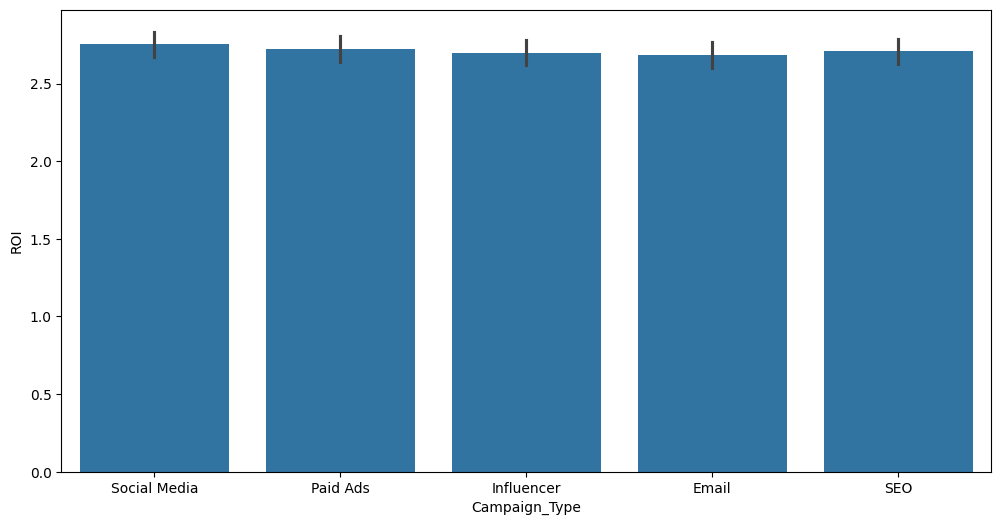

In [15]:
#bar chart of campaign on roi
plt.figure(figsize=(12, 6))
sns.barplot(x='Campaign_Type', y='ROI', data=df)

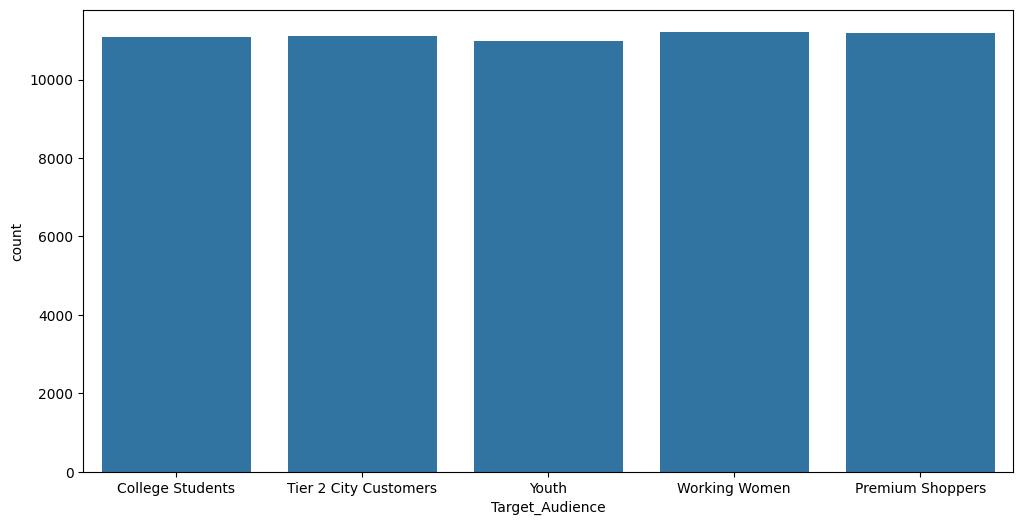

In [16]:
plt.figure(figsize=(12, 6))
sns.countplot(x='Target_Audience', data=df)
plt.show()

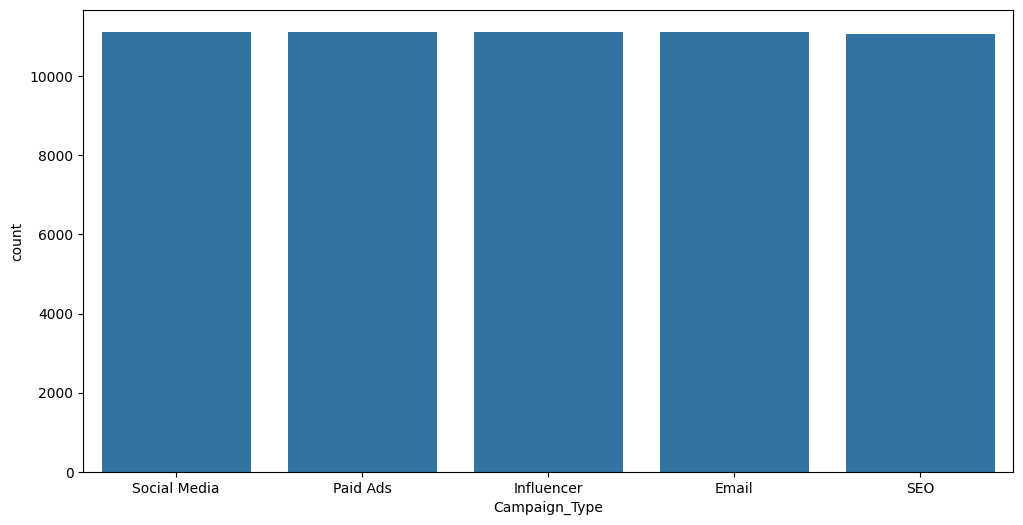

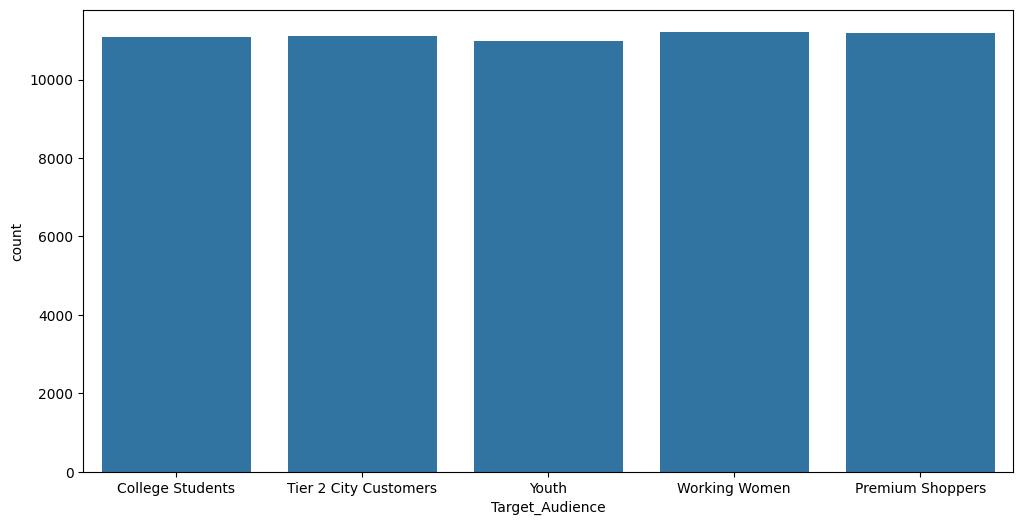

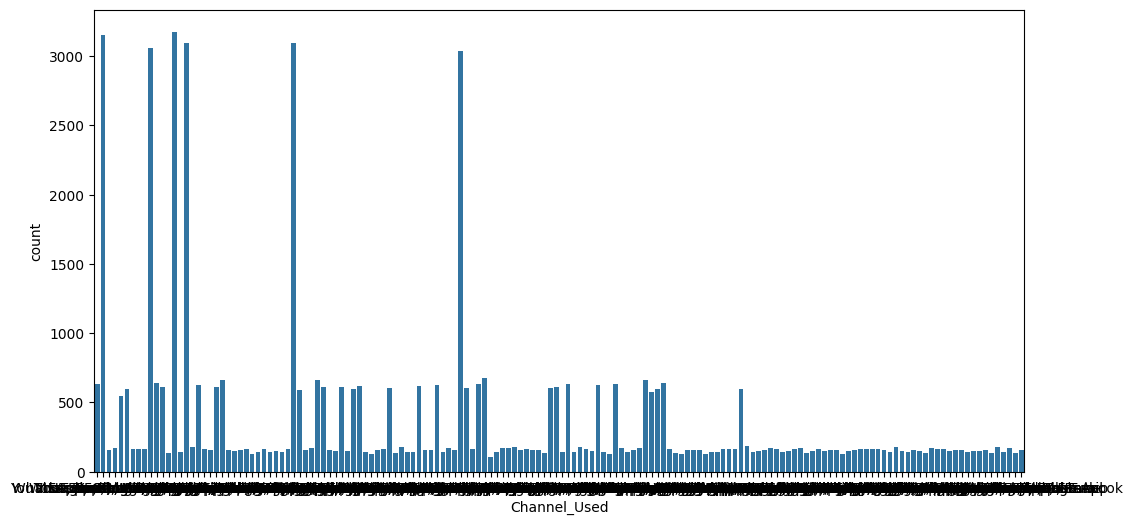

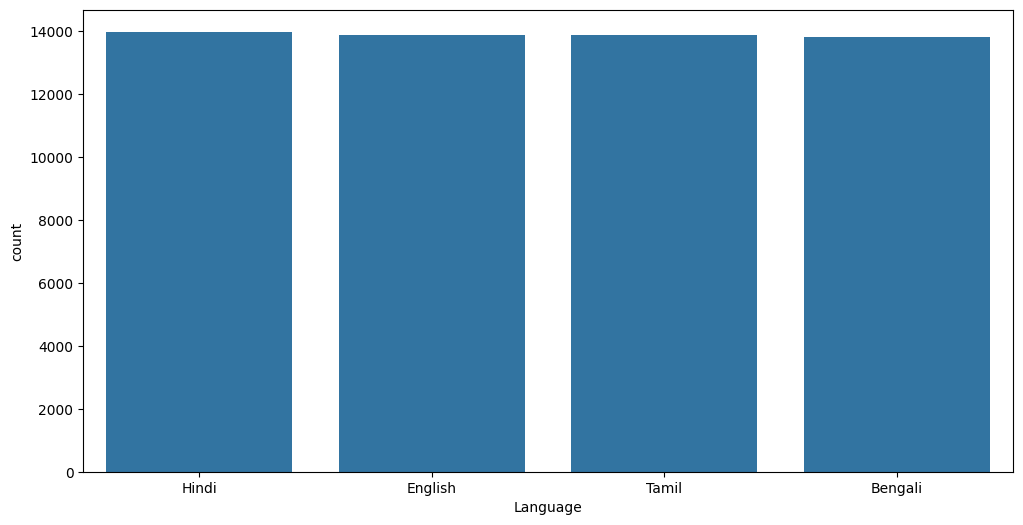

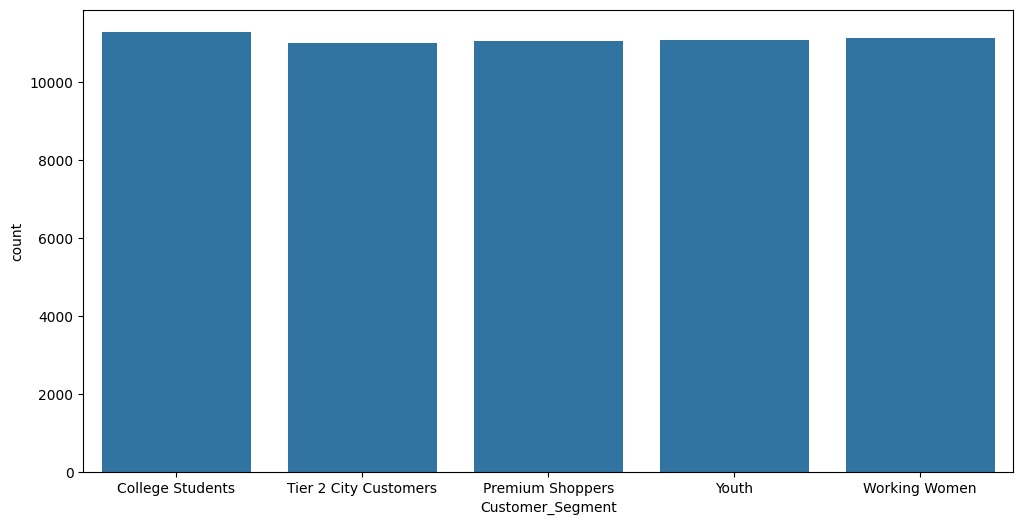

In [17]:
#using the for loop create bar chart on categorical columns
for col in categorical_cols:
    plt.figure(figsize=(12, 6))
    sns.countplot(x=col, data=df)
    plt.show()

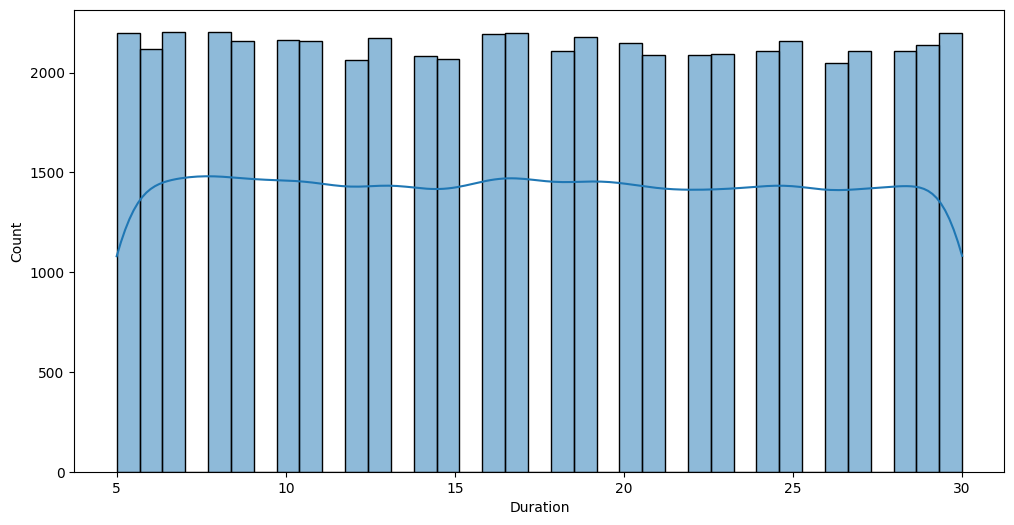

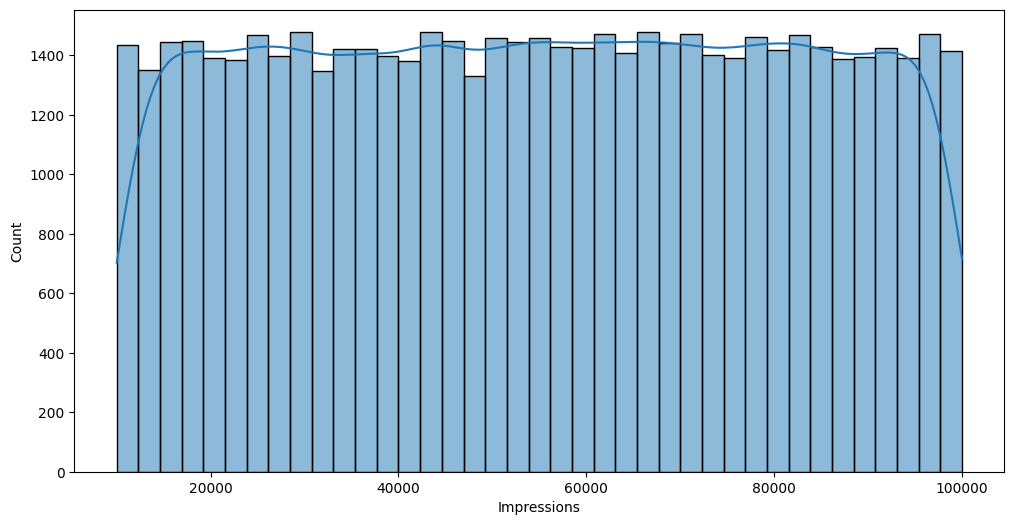

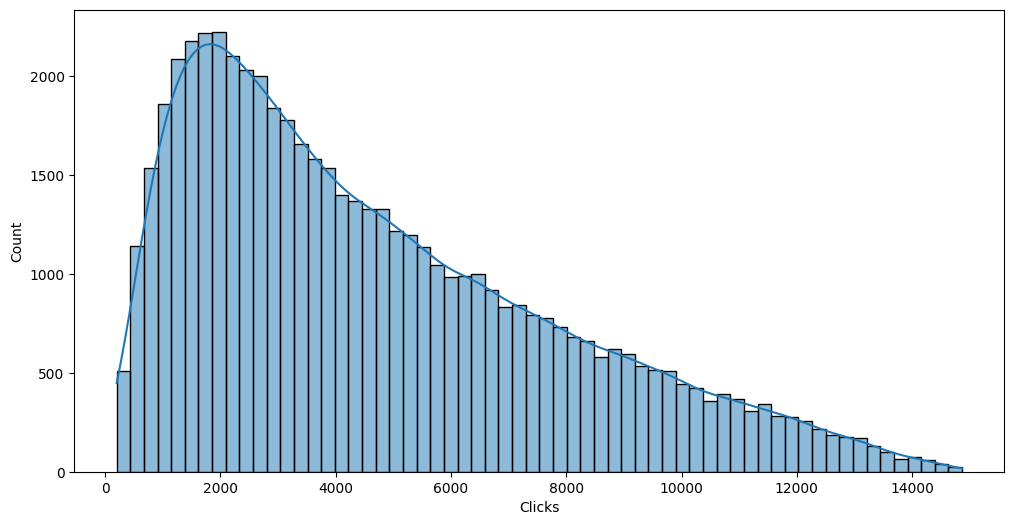

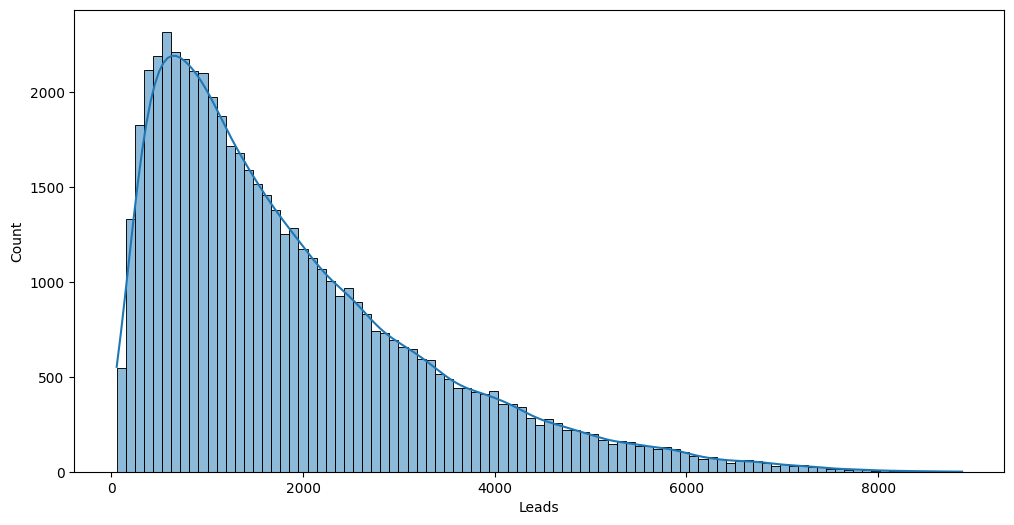

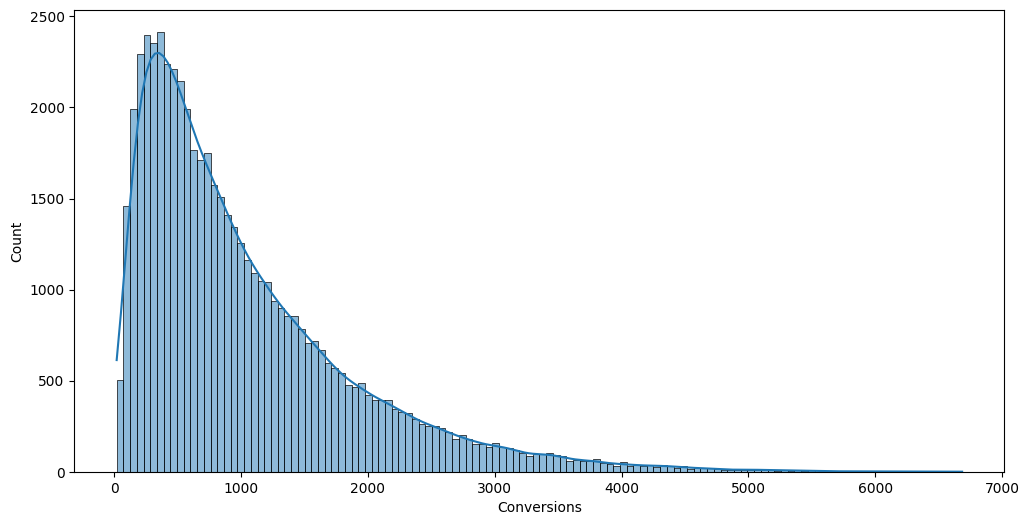

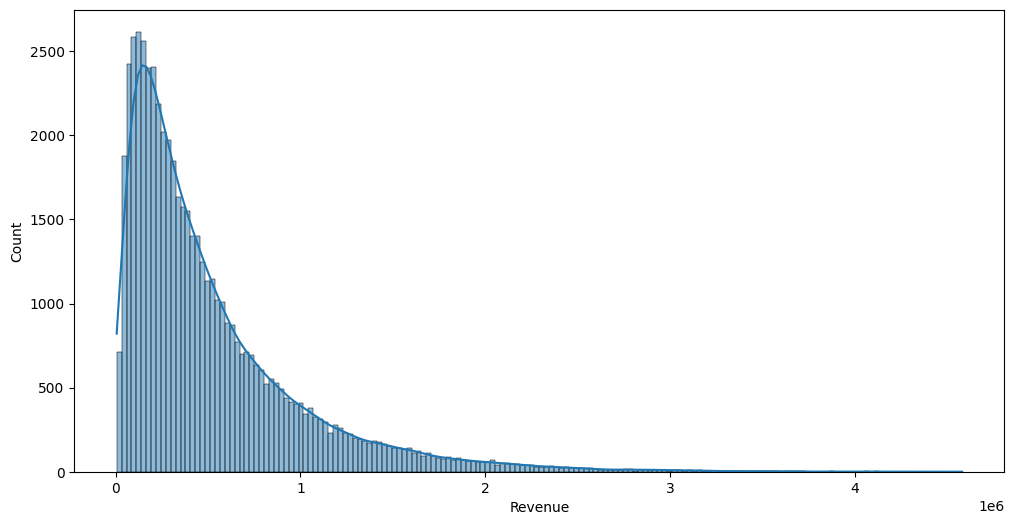

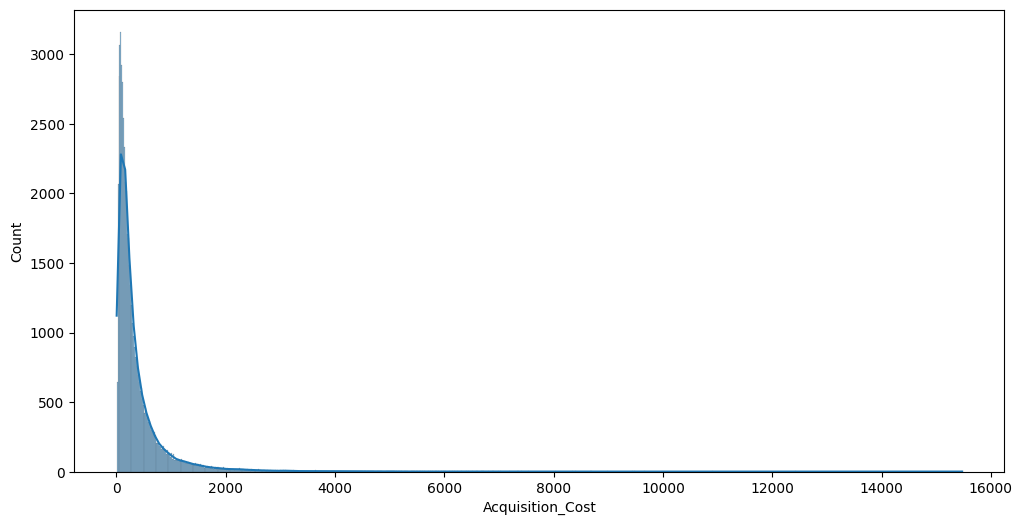

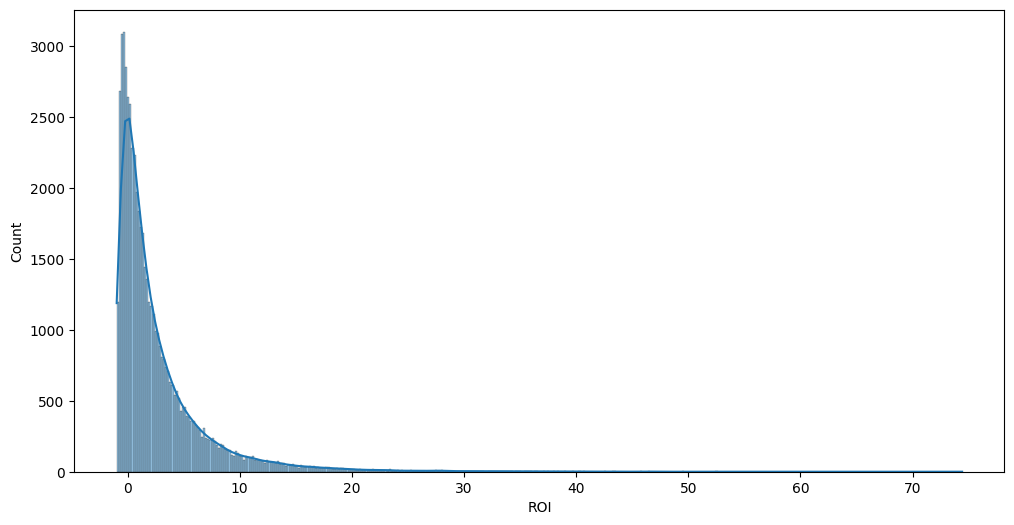

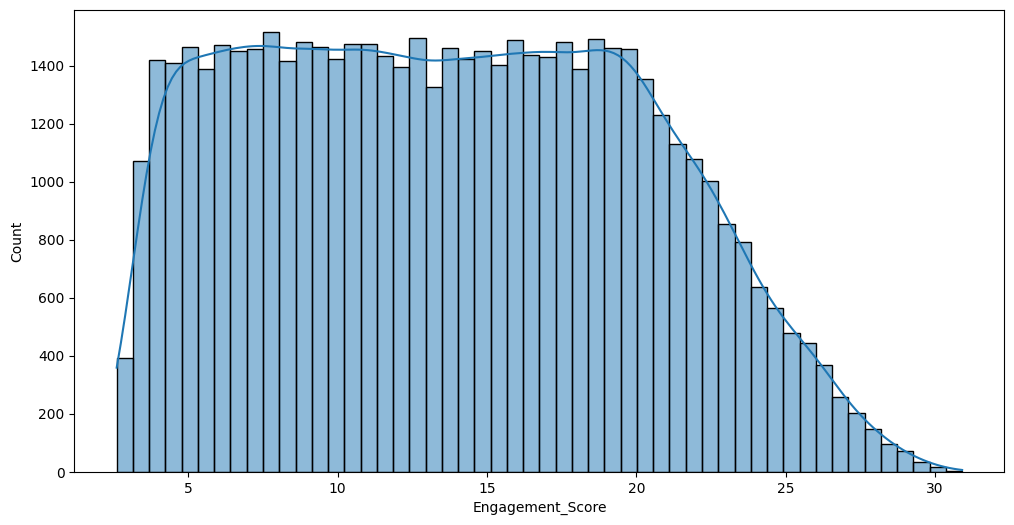

In [18]:
#using for loop to create graph on numerical column distribution
for col in numerical_cols:
    plt.figure(figsize=(12, 6))
    sns.histplot(df[col], kde=True)
    plt.show()

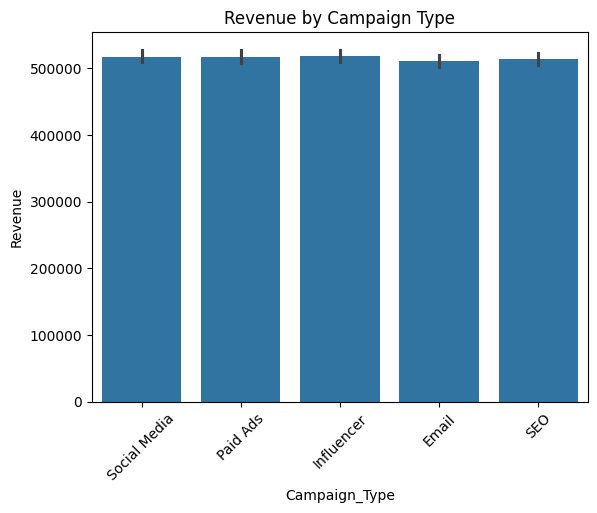

In [19]:
#Revenue by Campaign Type
sns.barplot(x='Campaign_Type', y='Revenue', data=df)
plt.title('Revenue by Campaign Type')
plt.xticks(rotation=45)
plt.show()

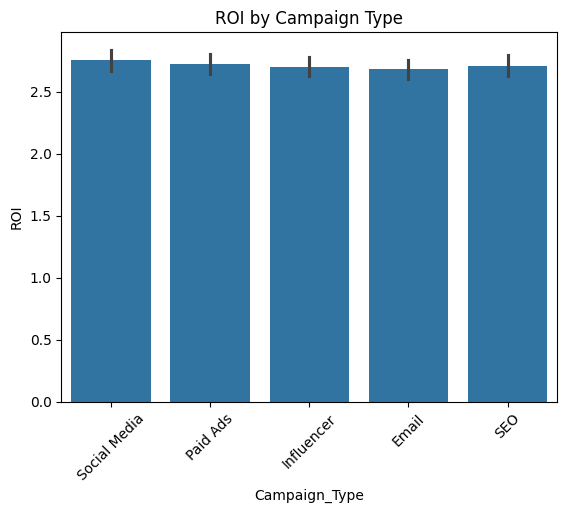

In [20]:
#ROI by Campaign Type
sns.barplot(x='Campaign_Type', y='ROI', data=df)
plt.title('ROI by Campaign Type')
plt.xticks(rotation=45)
plt.show()

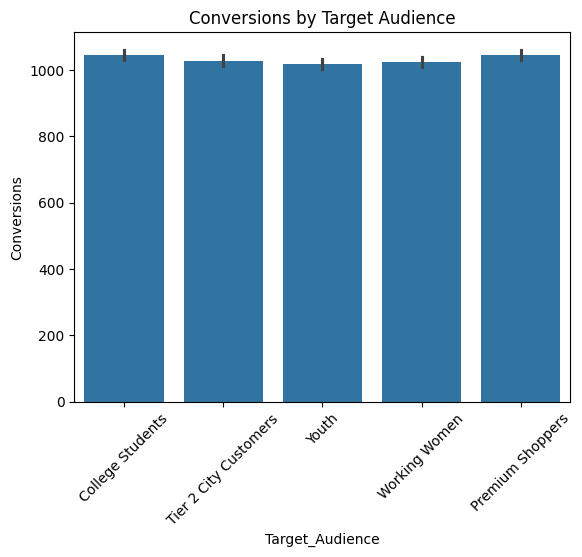

In [21]:
#Conversions by Target Audience
sns.barplot(x='Target_Audience', y='Conversions', data=df)
plt.title('Conversions by Target Audience')
plt.xticks(rotation=45)
plt.show()

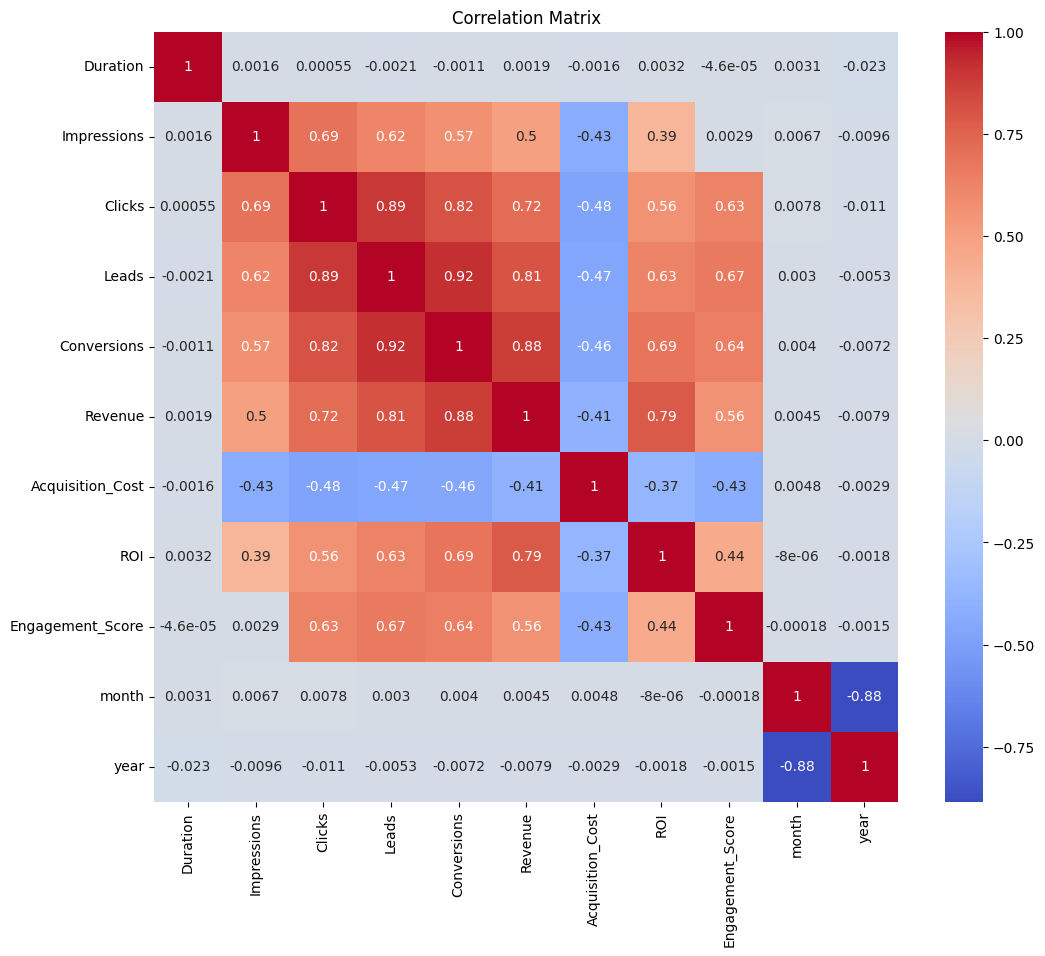

In [22]:
#Correlation Heatmap
corr = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

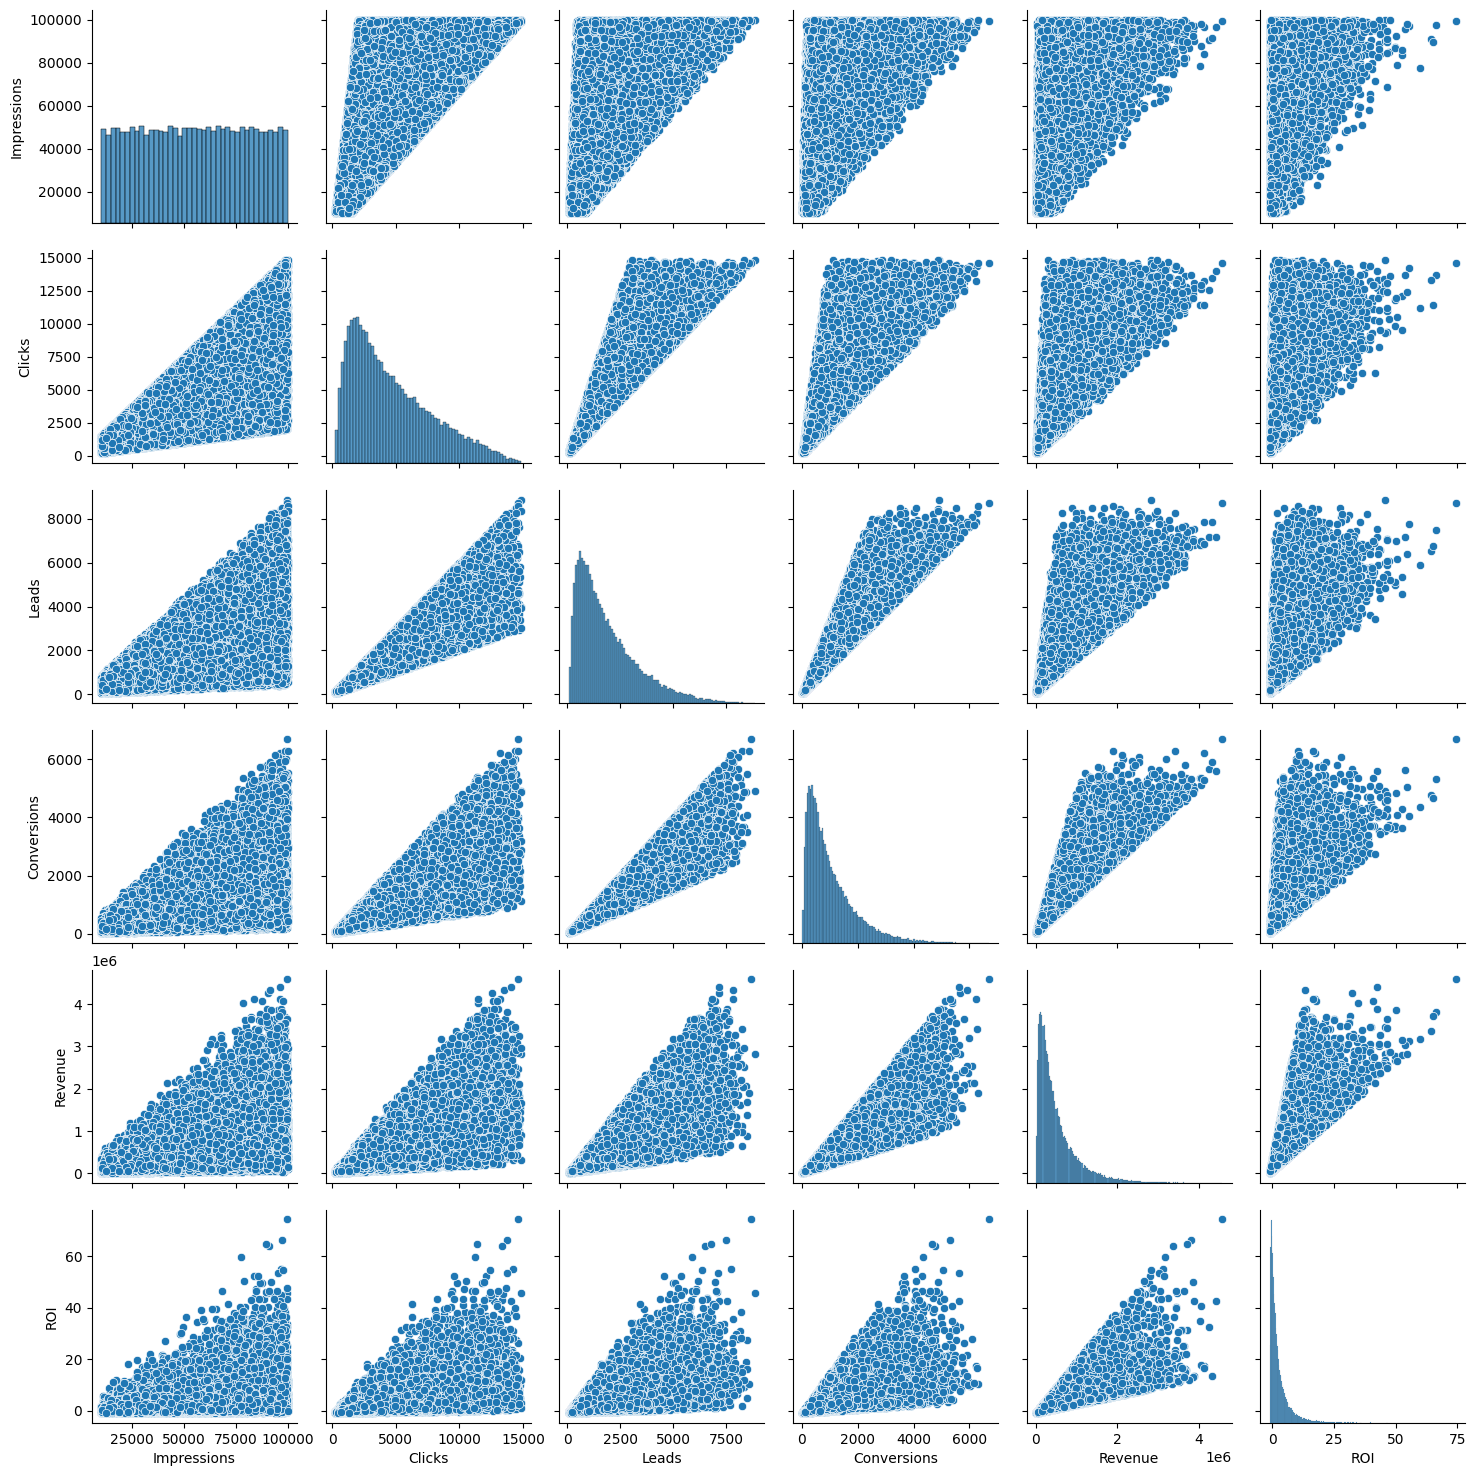

In [23]:
#pair plot
sns.pairplot(df[['Impressions','Clicks','Leads','Conversions','Revenue','ROI']])
plt.show()

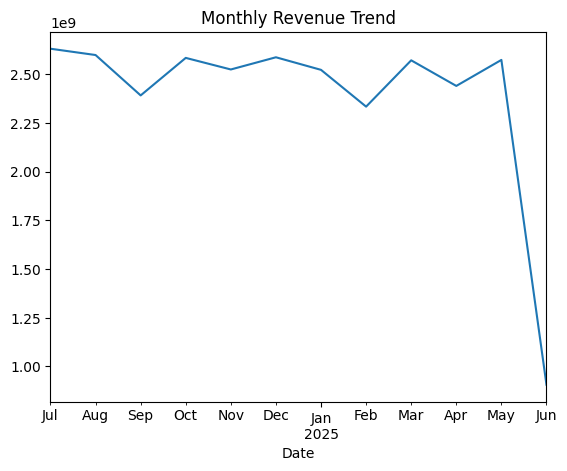

In [24]:
#Time Series Plot for Revenue Trend
df['Revenue'].resample('M').sum().plot()
plt.title('Monthly Revenue Trend')
plt.show()

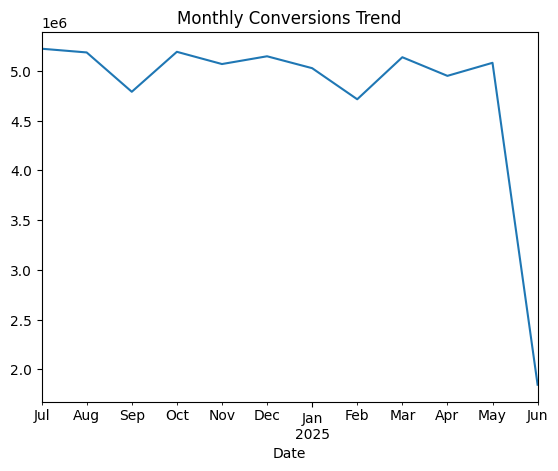

In [25]:
#Conversions Trend time series
df['Conversions'].resample('M').sum().plot()
plt.title('Monthly Conversions Trend')
plt.show()

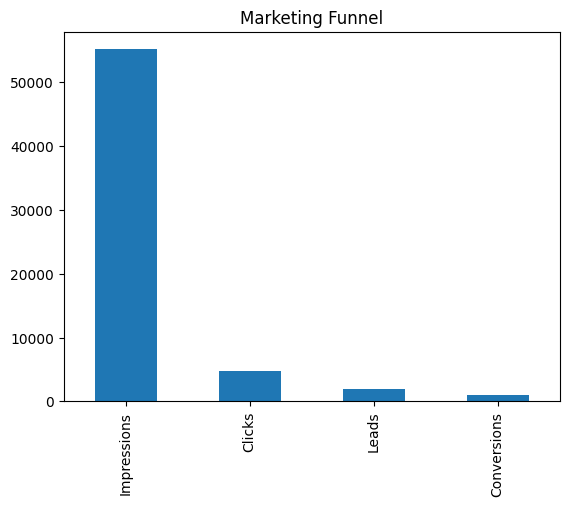

In [26]:
#Marketing Funnel Visualization
funnel = df[['Impressions','Clicks','Leads','Conversions']].mean()

funnel.plot(kind='bar')
plt.title('Marketing Funnel')
plt.show()

In [27]:
#Channel Performance
#Since Channel_Used has multiple platforms: so split it individually
df['Channel_Used'] = df['Channel_Used'].str.split(',')
df = df.explode('Channel_Used')

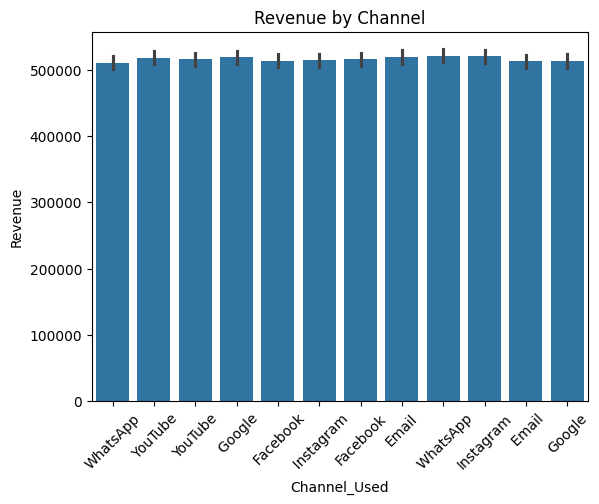

In [28]:
#Revenue by Channel
sns.barplot(x='Channel_Used', y='Revenue', data=df)
plt.title('Revenue by Channel')
plt.xticks(rotation=45)
plt.show()

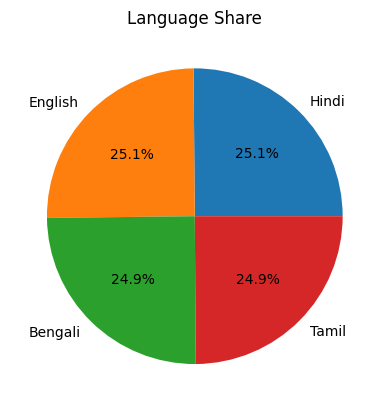

In [29]:
#Pie Charts
df['Language'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Language Share')
plt.ylabel('')
plt.show()

#***Create new metrics:-***

In [30]:
#Create new metrics:-
df['CTR'] = df['Clicks'] / df['Impressions']
df['Lead_Rate'] = df['Leads'] / df['Clicks']
df['Conversion_Rate'] = df['Conversions'] / df['Leads']

In [31]:
df['Cost_per_Click'] = df['Acquisition_Cost'] / df['Clicks']
df['Cost_per_Conversion'] = df['Acquisition_Cost'] / df['Conversions']

In [32]:
df['Revenue_per_Click'] = df['Revenue'] / df['Clicks']

In [33]:
df['Engagement_Level'] = pd.cut(df['Engagement_Score'],
                               bins=[0,10,20,30,40],
                               labels=['Low','Medium','High','Very High'])

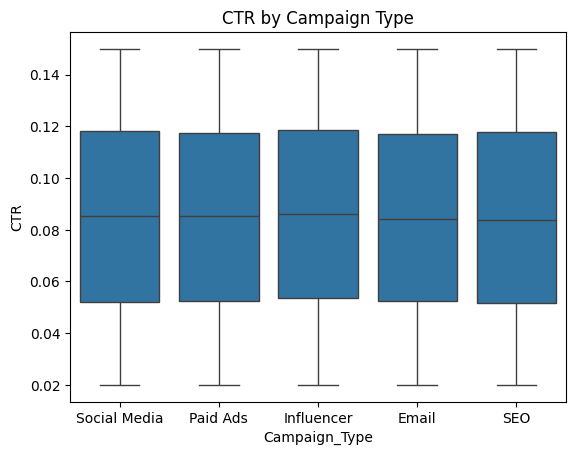

In [34]:
#campaign type gets more clicks
sns.boxplot(x='Campaign_Type', y='CTR', data=df)
plt.title('CTR by Campaign Type')
plt.show()

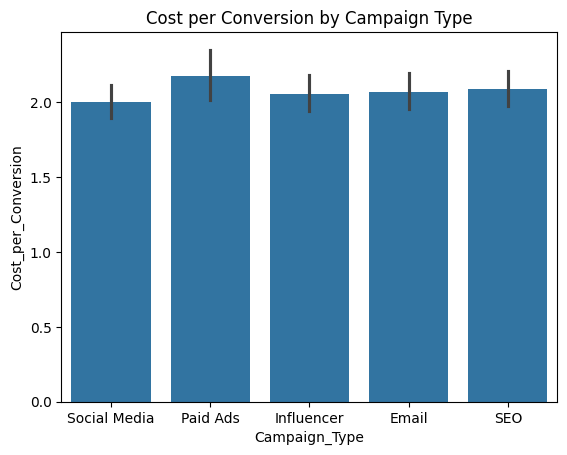

In [35]:
sns.barplot(x='Campaign_Type', y='Cost_per_Conversion', data=df)
plt.title('Cost per Conversion by Campaign Type')
plt.show()

<Axes: xlabel='Channel_Used', ylabel='Revenue_per_Click'>

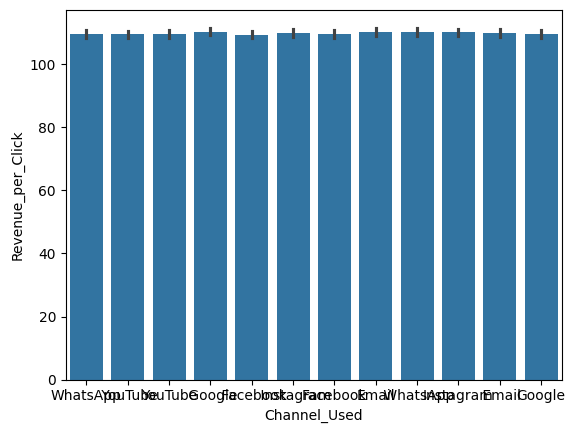

In [36]:
sns.barplot(x='Channel_Used', y='Revenue_per_Click', data=df)

Text(0.5, 1.0, 'Duration vs ROI')

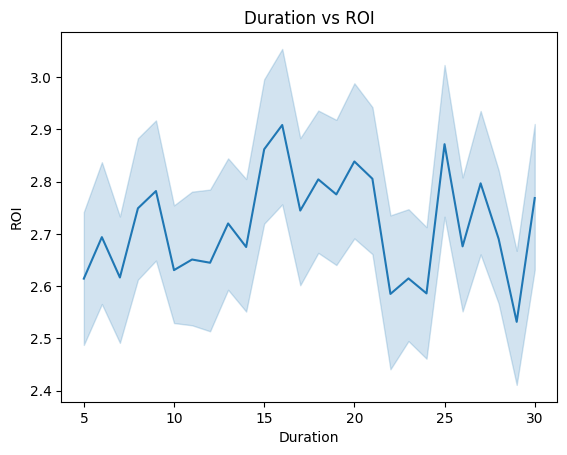

In [37]:
sns.lineplot(x='Duration', y='ROI', data=df)
plt.title('Duration vs ROI')

<Axes: xlabel='Engagement_Level', ylabel='count'>

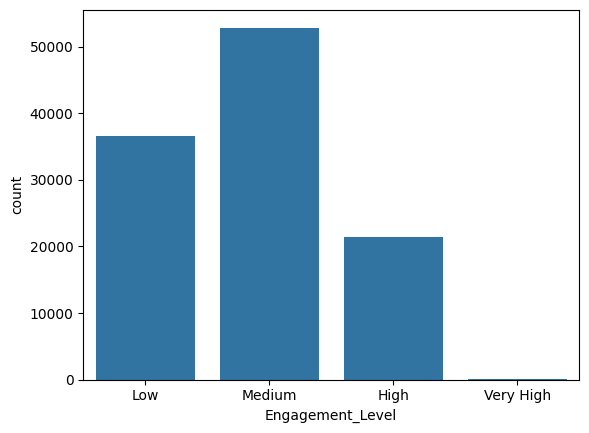

In [38]:
sns.countplot(x='Engagement_Level', data=df)

#***Outlier Investigation:-***

In [39]:
Q1 = df['Revenue'].quantile(0.25)
Q3 = df['Revenue'].quantile(0.75)

IQR = Q3 - Q1

outliers = df[(df['Revenue'] < Q1 - 1.5*IQR) | (df['Revenue'] > Q3 + 1.5*IQR)]

<Axes: xlabel='Customer_Segment', ylabel='ROI'>

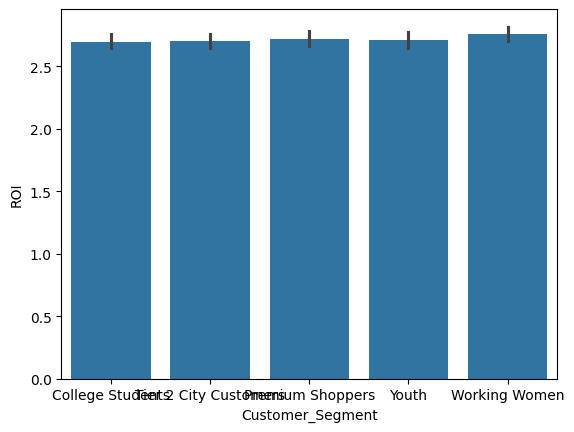

In [40]:
sns.barplot(x='Customer_Segment', y='ROI', data=df)

<Axes: xlabel='Date'>

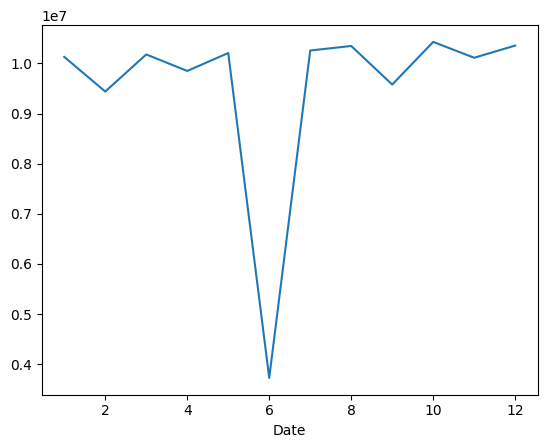

In [41]:
df.groupby(df.index.month)['Conversions'].sum().plot()

#***Drop Some Features not nessary creating model:-***

In [42]:
#drop the date column as this is not a series dataset we use the data to predict the advtisement related feature
#check the index as date column not shown as features in dataset
df.index

DatetimeIndex(['2025-04-29', '2025-04-29', '2025-04-06', '2025-01-14',
               '2025-01-14', '2025-01-14', '2025-06-04', '2025-06-04',
               '2025-06-04', '2024-12-29',
               ...
               '2025-02-16', '2024-11-18', '2024-10-24', '2024-10-24',
               '2024-10-24', '2025-05-22', '2025-05-22', '2025-05-30',
               '2025-05-30', '2025-05-30'],
              dtype='datetime64[ns]', name='Date', length=110903, freq=None)

In [43]:
#drop date index as we realise date index not required and Reset the index
df.reset_index(drop=True, inplace=True)

In [45]:
df.columns

Index(['Campaign_Type', 'Target_Audience', 'Duration', 'Channel_Used',
       'Impressions', 'Clicks', 'Leads', 'Conversions', 'Revenue',
       'Acquisition_Cost', 'ROI', 'Language', 'Engagement_Score',
       'Customer_Segment', 'month', 'year', 'CTR', 'Lead_Rate',
       'Conversion_Rate', 'Cost_per_Click', 'Cost_per_Conversion',
       'Revenue_per_Click', 'Engagement_Level'],
      dtype='object')